<a href="https://colab.research.google.com/github/katsuhiro-wq/katsuhiro-wq/blob/sub1/%E3%82%B7%E3%83%A3%E3%83%B3%E3%83%88%E9%9F%B3%E8%A7%A3%E6%9E%90%E3%82%B5%E3%83%B3%E3%83%97%E3%83%AB%E3%82%B3%E3%83%BC%E3%83%89_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, iirnotch
import soundfile as sf
import csv

In [2]:
# === シャント音の録音ファイルを読み込む（10秒間録音） ===
filename = 'audio.wav'  # 音声ファイルのパス
# librosa.loadで音声ファイルを読み込み、波形データ y とサンプリングレート sr を取得
y, sr = librosa.load(filename)  # duration=10をつけると最初の10秒間のみ読み込む

In [3]:
# === バンドパスフィルタの設計 ===
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs  # ナイキスト周波数を計算
    low = lowcut / nyq  # 正規化した低周波数（0〜1の範囲）
    high = highcut / nyq  # 正規化した高周波数（0〜1の範囲）
    b, a = butter(order, [low, high], btype='band')  # バンドパスフィルタの係数を計算
    return b, a

In [4]:
# === ノッチフィルタの設計と適用 ===
def apply_notch_filter(signal, freq, fs, quality_factor=30):
    # ノッチ周波数を正規化（0〜1の範囲）
    w0 = freq / (fs / 2)
    # ノッチフィルタの係数を計算
    b, a = iirnotch(w0, quality_factor)
    # フィルタを適用してノッチング
    y_notched = lfilter(b, a, signal)
    return y_notched

filtered_shunt_sound.wav を保存しました。


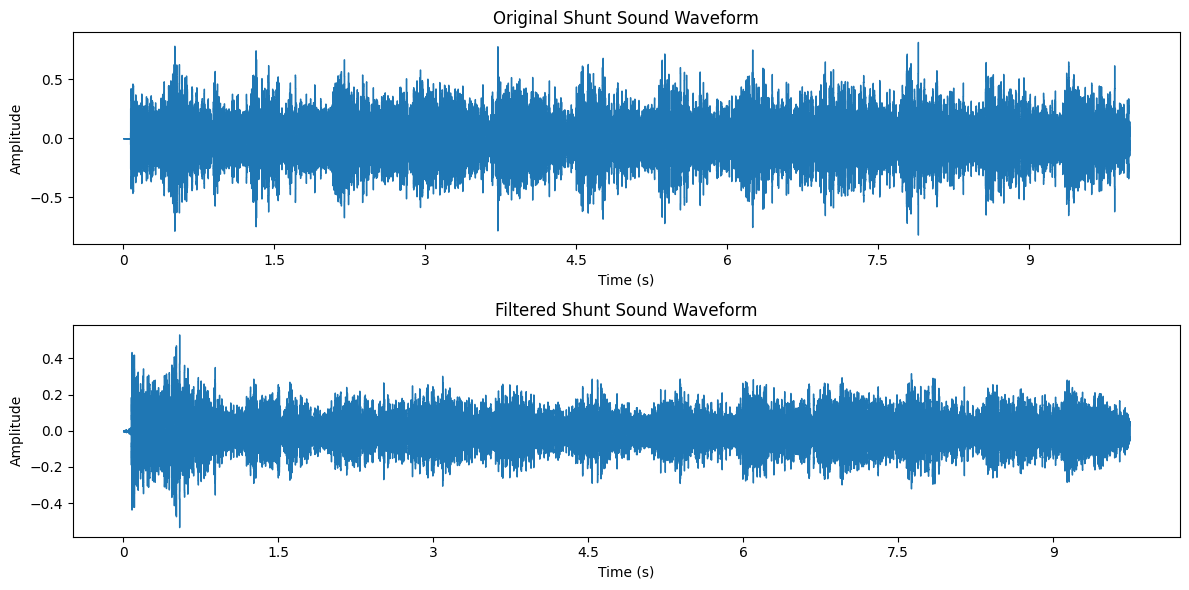

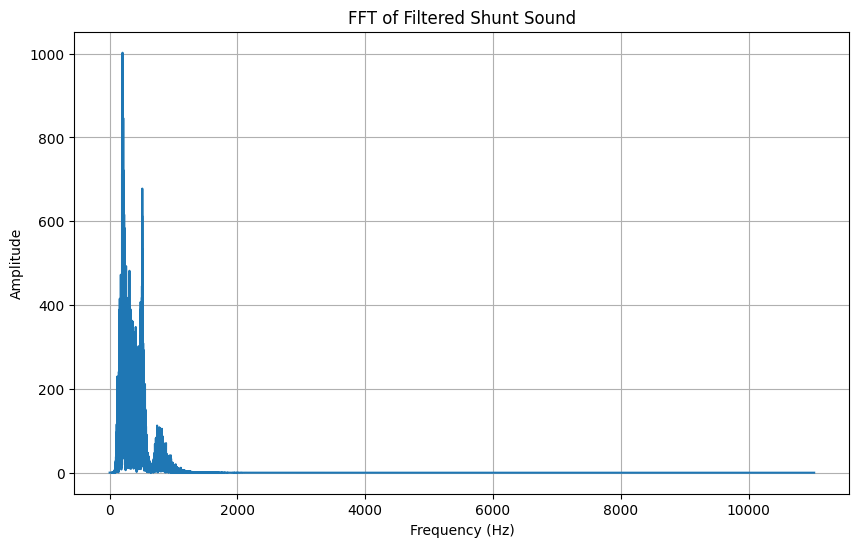

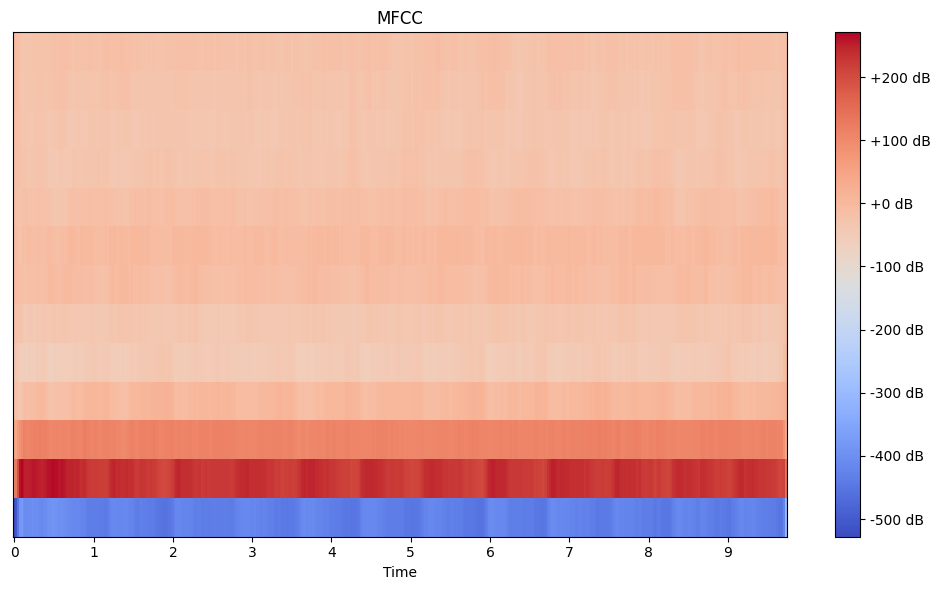

Peak Frequency: 202.02 Hz
MFCC Mean Coefficients: [-428.87915183  229.62100728  110.6442337     1.86830872  -44.48452833
  -34.22396226   -9.54555384   -3.01556797  -15.08658994  -28.06497157
  -30.63175781  -25.53436274  -20.00401985]


In [25]:
# === フィルタリングの適用 ===
# フィルタのパラメータ設定
lowcut = 100.0  # 低周波数カットオフ（Hz）
highcut = 1000.0  # 高周波数カットオフ（Hz）

# バンドパスフィルタを設計し、信号に適用
b, a = butter_bandpass(lowcut, highcut, sr, order=5)
y_filtered = lfilter(b, a, y)

# ノッチフィルタの適用（例として50Hzを除去）
notch_freq = 50.0  # ノッチフィルタの周波数（Hz）
y_filtered = apply_notch_filter(y_filtered, notch_freq, sr)

# === フィルタ処理後の波形をWAV形式で保存 ===
output_filename = "filtered_shunt_sound.wav"  # 出力ファイル名
sf.write(output_filename, y_filtered, sr)  # 波形データをWAVファイルとして保存

print(f"{output_filename} を保存しました。")

# === フィルタ前後の波形をプロット ===
plt.figure(figsize=(12, 6))

# オリジナルの波形
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_original, sr=sr)
plt.title("Original Shunt Sound Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# フィルタ後の波形
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_filtered, sr=sr)
plt.title("Filtered Shunt Sound Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# === FFT（フーリエ変換）による周波数解析 ===
fft_result = np.fft.fft(y_filtered)  # フーリエ変換を実行
fft_freqs = np.fft.fftfreq(len(fft_result), d=1/sr)  # 周波数軸を計算

# 振幅スペクトルをプロット（正の周波数成分のみ）
plt.figure(figsize=(10, 6))
plt.plot(fft_freqs[:len(fft_freqs)//2], np.abs(fft_result[:len(fft_result)//2]))
plt.title("FFT of Filtered Shunt Sound")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# === MFCC（メル周波数ケプストラム係数）の計算 ===
mfccs = librosa.feature.mfcc(y=y_filtered, sr=sr, n_mfcc=13)  # 13次のMFCCを計算

# MFCCをプロット
plt.figure(figsize=(10, 6))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('MFCC')
plt.tight_layout()
plt.show()

# === 特徴量の抽出（MFCCの係数やFFTのピークなど） ===
# ピーク周波数を計算（振幅が最大の周波数）
peak_idx = np.argmax(np.abs(fft_result[:len(fft_result)//2]))  # 正の周波数成分のみを考慮
peak_frequency = fft_freqs[peak_idx]

# MFCCの平均値を計算（各係数ごと）
mfcc_mean = np.mean(mfccs, axis=1)

with open('features.csv', 'w', newline='') as csvfile:
       writer = csv.writer(csvfile)
       writer.writerow(['peak_frequency'] + [f'mfcc_{i}' for i in range(13)])  # ヘッダー行
       writer.writerow([peak_frequency] + list(mfcc_mean))  # 特徴量データ

print(f"Peak Frequency: {peak_frequency:.2f} Hz")
print(f"MFCC Mean Coefficients: {mfcc_mean}")


以下は恣意的にカットオフを決める場合

In [26]:

# === 判定部分の例（シャント不全と比較する処理） ===
threshold_frequency = 200  # シャント不全の周波数基準（Hz）（例）
frequency_tolerance = 20  # 許容範囲（Hz）

# ピーク周波数と基準値を比較して判定
if abs(peak_frequency - threshold_frequency) < frequency_tolerance:
    print("シャント不全の可能性あり")
else:
    print("正常なシャント音")

シャント不全の可能性あり


In [28]:
import librosa
import numpy as np
import os
import soundfile as sf

# === オリジナルのシャント音録音ファイルを読み込む（10秒間録音） ===
filename = 'audio.wav'  # オリジナル音声ファイルのパス
# librosa.loadで音声ファイルを読み込み、波形データ y_original とサンプリングレート sr を取得
y_original, sr = librosa.load(filename, duration=10)  # duration=10 で最初の10秒間のみを読み込む

# === シミュレーションで似たようなファイルを50個作成 ===

# 出力ディレクトリの設定
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ
if not os.path.exists(output_dir):
    os.makedirs(output_dir)  # ディレクトリが存在しない場合は作成

# シミュレーションのパラメータ範囲の設定
noise_levels = np.linspace(0.001, 0.01, 50)  # ノイズレベルの範囲（50段階）
pitch_shift_steps = np.linspace(-2, 2, 50)  # ピッチシフトの範囲（半音単位、50段階）
time_stretch_rates = np.linspace(0.9, 1.1, 50)  # タイムストレッチの範囲（50段階）

# 乱数シードの設定（結果の再現性のため）
np.random.seed(42)

for i in range(50):
    y_simulated = y_original.copy()  # オリジナル音声をコピー

    # === ランダムなノイズを追加 ===
    noise_level = np.random.choice(noise_levels)  # ノイズレベルをランダムに選択
    noise = noise_level * np.random.randn(len(y_simulated))  # ガウスノイズを生成
    y_simulated += noise  # ノイズを音声に追加

    # === ランダムなピッチシフトを適用 ===
    n_steps = np.random.choice(pitch_shift_steps)  # ピッチシフト量をランダムに選択
    # pitch_shift の呼び出しを更新し、必要なパラメータをキーワード引数で渡す
    y_simulated = librosa.effects.pitch_shift(y=y_simulated, sr=sr, n_steps=n_steps)

    # === ランダムなタイムストレッチを適用 ===
    rate = np.random.choice(time_stretch_rates)  # タイムストレッチ率をランダムに選択
    # time_stretch() now expects a dictionary as input
    y_simulated = librosa.effects.time_stretch(y=y_simulated, rate=rate)

    # === シミュレーション音声をファイルに保存 ===
    output_filename = f'simulated_shunt_{i+1:02d}.wav'  # 出力ファイル名を連番で作成
    output_path = os.path.join(output_dir, output_filename)
    sf.write(output_path, y_simulated, sr)  # 音声ファイルを保存

    #print(f"{output_filename} を生成しました。")  # 進行状況を表示

In [29]:
import os
import csv
import random
import librosa
import numpy as np
import pandas as pd

# === ラベル作成処理 ===
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ
threshold_frequency = 200  # シャント不全の周波数基準（Hz）（例）
frequency_tolerance = 20  # 許容範囲（Hz）

# ラベルを保存するCSVファイルを開く
with open('ground_truth_labels.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])  # ヘッダー行を書き込む

    for filename in os.listdir(output_dir):
        if filename.endswith('.wav'):
            filepath = os.path.join(output_dir, filename)
            y, sr = librosa.load(filepath)

            # FFT（フーリエ変換）による周波数解析
            fft_result = np.fft.fft(y)  # フーリエ変換を実行
            fft_freqs = np.fft.fftfreq(len(fft_result), d=1 / sr)  # 周波数軸を計算

            # ピーク周波数を計算（振幅が最大の周波数）
            peak_idx = np.argmax(np.abs(fft_result[:len(fft_result) // 2]))  # 正の周波数成分のみを考慮
            peak_frequency = fft_freqs[peak_idx]

            # ピーク周波数と基準値を比較してラベルを決定
            if abs(peak_frequency - threshold_frequency) < frequency_tolerance:
                label = 'true'  # シャント不全の可能性あり
            else:
                label = 'false'  # 正常なシャント音

            # ファイル名とラベルをCSVファイルに書き込む
            writer.writerow([filename, label])

print("ground_truth_labels.csv が作成されました。")

# === 感度と特異度の計算 ===
# 予測ラベルを読み込む (predicted labels) - ここではground_truthと同じものを使用
predicted_labels = {}
with open('ground_truth_labels.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # ヘッダー行をスキップ
    for row in reader:
        predicted_labels[row[0]] = row[1]

# 真陽性 (TP)、偽陽性 (FP)、真陰性 (TN)、偽陰性 (FN) をカウント
TP = FP = TN = FN = 0
for filename in predicted_labels:
    ground_truth = predicted_labels[filename] # ground_truthとpredicted_labelsは同じ
    predicted = predicted_labels[filename]

    if ground_truth == 'true' and predicted == 'true':
        TP += 1
    elif ground_truth == 'false' and predicted == 'true':
        FP += 1
    elif ground_truth == 'false' and predicted == 'false':
        TN += 1
    elif ground_truth == 'true' and predicted == 'false':
        FN += 1

# 感度 (Sensitivity) と特異度 (Specificity) を計算
sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0  # ゼロ除算を回避
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0  # ゼロ除算を回避

print(f"感度 (Sensitivity): {sensitivity:.2f}")
print(f"特異度 (Specificity): {specificity:.2f}")

# Create a DataFrame 'df' with original data and predictions
# You'll need to replace this with your actual data and predictions
data = []
for filename in predicted_labels:
    ground_truth = predicted_labels[filename]  # ground_truth and predicted_labels are the same
    predicted = predicted_labels[filename]
    # Add any other relevant data you want to include in the DataFrame
    data.append([filename, ground_truth, predicted])  # Example: filename, ground truth, prediction

df = pd.DataFrame(data, columns=['filename', 'ground_truth', 'prediction'])

# Displaying results using pandas' display function
results = {'Sensitivity': [sensitivity], 'Specificity': [specificity]}
print("Sensitivity and Specificity Results:")
display(pd.DataFrame(results, index=[0]))  # Use display instead of ace_tools

# Assuming you have a pandas DataFrame named 'df' with original data and predictions
print("\nOriginal Data with Predictions:")
display(df)  # Use display instead of ace_tools

ground_truth_labels.csv が作成されました。
感度 (Sensitivity): 1.00
特異度 (Specificity): 1.00
Sensitivity and Specificity Results:


,Sensitivity,Specificity
0,1.0,1.0



Original Data with Predictions:


,filename,ground_truth,prediction
0,simulated_shunt_26.wav,false,false
1,simulated_shunt_49.wav,false,false
2,simulated_shunt_32.wav,false,false
3,simulated_shunt_42.wav,true,true
4,simulated_shunt_43.wav,true,true
5,simulated_shunt_17.wav,false,false
6,simulated_shunt_29.wav,true,true
7,simulated_shunt_03.wav,false,false
8,simulated_shunt_15.wav,false,false
9,simulated_shunt_21.wav,false,false


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.80
predicted_labels_logistic.csv が作成されました。


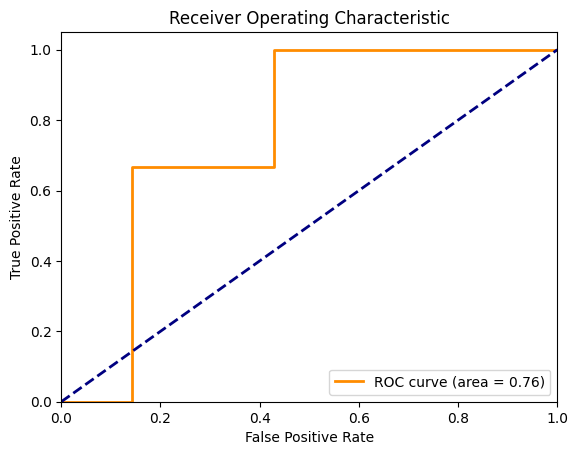

In [40]:
# 特徴量をMFCCとして機械学習　ロジスティック回帰
import librosa
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ... (他のimport文や前処理は省略) ...

# 特徴量抽出と機械学習
features = []
labels = []

for filename in os.listdir(output_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(output_dir, filename)
        y, sr = librosa.load(filepath)

        # MFCCの計算
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)  # 13次のMFCCを計算

        # MFCCの平均値を特徴量として使用
        mfcc_mean = np.mean(mfccs, axis=1)
        features.append(mfcc_mean)
        labels.append(ground_truth_labels[filename])

# 特徴量とラベルをNumPy配列に変換
features = np.array(features)
labels = np.array(labels)

# データを訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# ロジスティック回帰モデルを訓練
model = LogisticRegression()
model.fit(X_train, y_train)

# テストデータで予測
y_pred = model.predict(X_test)

# 精度を評価
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# 予測結果をCSVファイルに保存 (ロジスティック回帰用)
with open('predicted_labels_logistic.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])

    # 全てのファイル名をリスト化
    all_filenames = [filename for filename in os.listdir(output_dir) if filename.endswith('.wav')]

    # train_test_splitで分割した時と同じように、ファイル名を訓練用とテスト用に分割
    train_filenames, test_filenames, _, _ = train_test_split(all_filenames, labels, test_size=0.2, random_state=42)

    for i, filename in enumerate(all_filenames):
        if filename in test_filenames:
            # テストデータに含まれるファイルは、既に予測済みなので、その結果を使用
            index_in_test_set = test_filenames.index(filename)
            writer.writerow([filename, y_pred[index_in_test_set]])
        else:
            # テストデータに含まれていないファイルは、モデルで予測
            filepath = os.path.join(output_dir, filename)
            y, sr = librosa.load(filepath)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfccs, axis=1)
            prediction = model.predict(mfcc_mean.reshape(1, -1))[0] # 予測前にmfcc_meanの形状を調整
            writer.writerow([filename, prediction])

print("predicted_labels_logistic.csv が作成されました。")

# Convert y_test to numerical values
y_test_numeric = [1 if label == 'true' else 0 for label in y_test]

# ROC曲線を計算
# Pass y_test_numeric and specify pos_label='true'
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

# ROC曲線をプロット
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Accuracy: 0.70
predicted_labels_logistic.csv が作成されました。


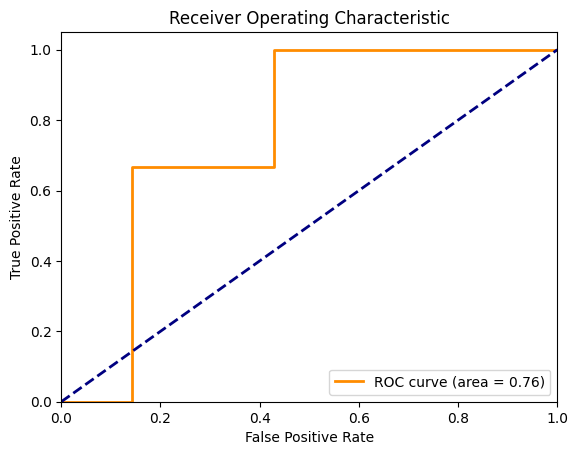

In [38]:
#特徴量を音声のゼロ交差率とスペクトル重心を抽出として機械学習　ロジスティック回帰
import os
import csv
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# === 前のセクションで作成したground_truth_labelsを読み込む ===
ground_truth_labels = {}  # ファイル名とラベルを格納する辞書
with open('ground_truth_labels.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # ヘッダー行をスキップ
    for row in reader:
        ground_truth_labels[row[0]] = row[1]

# === 特徴量抽出と機械学習 ===
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ

# 特徴量を保存するリスト
features = []
labels = []

# Wrap the code that accesses the directory in a try-except block
try:
    for filename in os.listdir(output_dir):
        if filename.endswith('.wav'):
            filepath = os.path.join(output_dir, filename)
            y, sr = librosa.load(filepath)

            # 特徴量として、音声のゼロ交差率とスペクトル重心を抽出
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y).mean()
            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()

            features.append([zero_crossing_rate, spectral_centroid])
            labels.append(ground_truth_labels[filename])  # ground_truth_labelsからラベルを取得

except FileNotFoundError:
    print(f"Error: Directory '{output_dir}' not found. Please make sure it exists and contains the audio files.")

# 特徴量とラベルをNumPy配列に変換
features = np.array(features)
labels = np.array(labels)

# データを訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# ロジスティック回帰モデルを訓練
model = LogisticRegression()
model.fit(X_train, y_train)

# テストデータで予測
y_pred = model.predict(X_test)

# 精度を評価
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# 予測結果をCSVファイルに保存 (ロジスティック回帰用)
with open('predicted_labels_logistic.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])

    # 全てのファイル名をリスト化
    all_filenames = [filename for filename in os.listdir(output_dir) if filename.endswith('.wav')]

    # train_test_splitで分割した時と同じように、ファイル名を訓練用とテスト用に分割
    train_filenames, test_filenames, _, _ = train_test_split(all_filenames, labels, test_size=0.2, random_state=42)

    for i, filename in enumerate(all_filenames):
        if filename in test_filenames:
            # テストデータに含まれるファイルは、既に予測済みなので、その結果を使用
            index_in_test_set = test_filenames.index(filename)
            writer.writerow([filename, y_pred[index_in_test_set]])
        else:
            # Predict for files not in the test set using the correct features
            filepath = os.path.join(output_dir, filename)
            y, sr = librosa.load(filepath)

            # Extract the same features used for training
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y).mean()
            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()

            # Reshape the features for prediction
            prediction_features = np.array([zero_crossing_rate, spectral_centroid]).reshape(1, -1)

            # Make prediction
            prediction = model.predict(prediction_features)[0]
            writer.writerow([filename, prediction])

print("predicted_labels_logistic.csv が作成されました。")

# Convert y_test to numerical values
y_test_numeric = [1 if label == 'true' else 0 for label in y_test]

# ROC曲線を計算
# Pass y_test_numeric and specify pos_label='true'
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

# ROC曲線をプロット
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

SVM Accuracy: 0.70


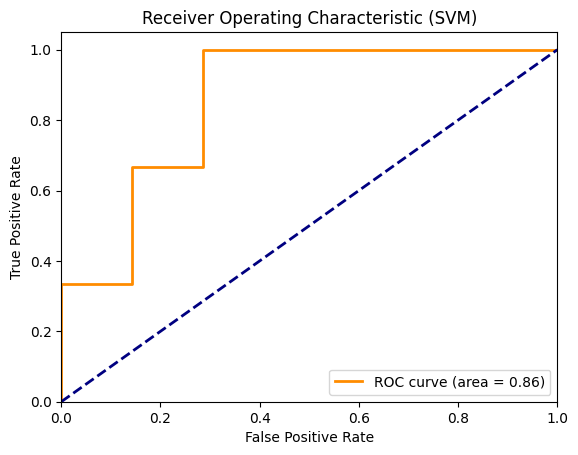

ROC curve data saved to roc_curve_data.csv


In [41]:
#特徴量を徴量を音声のゼロ交差率とスペクトル重心を抽出としSVMを実行
import librosa
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import csv

# Assuming you have your audio files in a directory called 'simulated_shunt_sounds'
output_dir = 'simulated_shunt_sounds'

# Load ground truth labels (if you have a separate file)
ground_truth_labels = {}
with open('ground_truth_labels.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # Skip header row
    for row in reader:
        ground_truth_labels[row[0]] = row[1]

features = []
labels = []

for filename in os.listdir(output_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(output_dir, filename)
        y, sr = librosa.load(filepath)

        # Extract Zero Crossing Rate (ZCR)
        zcr = librosa.feature.zero_crossing_rate(y).mean()

        # Extract Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()

        features.append([zcr, spectral_centroid])
        labels.append(ground_truth_labels[filename])

features = np.array(features)
labels = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

svm_model = SVC(kernel='linear', probability=True)  # Use probability=True for predict_proba
svm_model.fit(X_train, y_train)

svm_y_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_y_pred)
print(f"SVM Accuracy: {svm_accuracy:.2f}")

# Convert labels to numerical values
y_test_numeric = [1 if label == 'true' else 0 for label in y_test]
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Calculate and plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (SVM)')
plt.legend(loc="lower right")
plt.show()

# Save ROC curve data to CSV
with open('roc_curve_data.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['False Positive Rate', 'True Positive Rate', 'Threshold'])
    for i in range(len(fpr)):
        writer.writerow([fpr[i], tpr[i], thresholds[i]])

print("ROC curve data saved to roc_curve_data.csv")

Random Forest Accuracy: 0.80


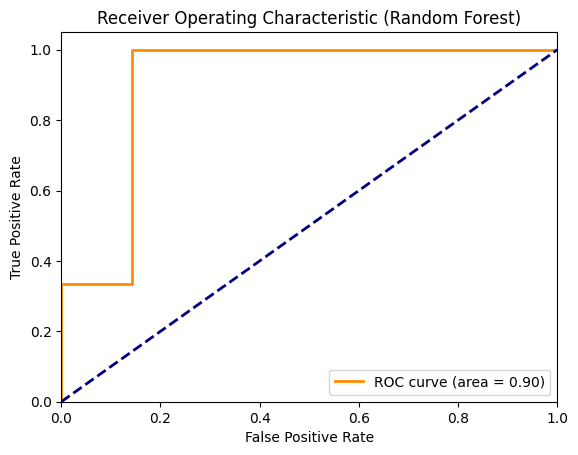

In [42]:
#徴量を音声のゼロ交差率とスペクトル重心を抽出としてランダムフォレストを実行
import librosa
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have your audio files in a directory called 'simulated_shunt_sounds'
output_dir = 'simulated_shunt_sounds'

# Load ground truth labels
ground_truth_labels = {}
with open('ground_truth_labels.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # Skip header row
    for row in reader:
        ground_truth_labels[row[0]] = row[1]

# Feature extraction
features = []
labels = []

for filename in os.listdir(output_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(output_dir, filename)
        y, sr = librosa.load(filepath)

        # Extract Zero Crossing Rate (ZCR)
        zcr = librosa.feature.zero_crossing_rate(y).mean()

        # Extract Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()

        features.append([zcr, spectral_centroid])
        labels.append(ground_truth_labels[filename])

# Convert to NumPy arrays
features = np.array(features)
labels = np.array(labels)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate accuracy
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

# (Optional) Plot ROC curve
# Convert labels to numerical values for ROC curve
y_test_numeric = [1 if label == 'true' else 0 for label in y_test]
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Random Forest)')
plt.legend(loc="lower right")
plt.show()

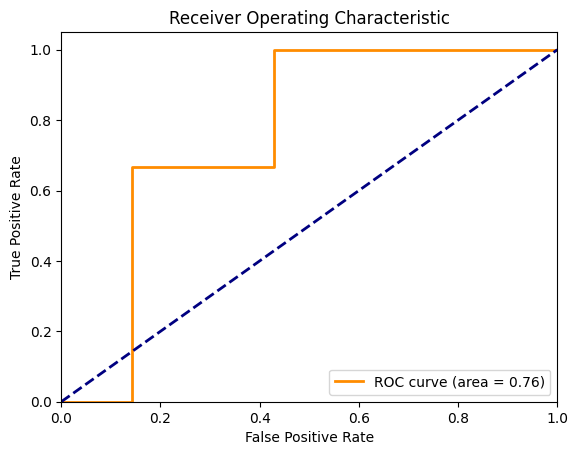

In [19]:
# @title
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ... (ロジスティック回帰の処理は省略) ...

# Convert y_test to numerical values
y_test_numeric = [1 if label == 'true' else 0 for label in y_test]

# ROC曲線を計算
# Pass y_test_numeric and specify pos_label='true'
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_proba[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

# ROC曲線をプロット
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# ... (他のimport文や前処理は省略) ...

# ランダムフォレストモデルの作成と学習
rf_model = RandomForestClassifier(n_estimators=100)  # 100本の決定木を使用
rf_model.fit(X_train, y_train)

# テストデータで予測
rf_y_pred = rf_model.predict(X_test)

# 精度を評価
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

# 予測結果をCSVファイルに保存 (ランダムフォレスト用)
with open('predicted_labels_rf.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])
    for i, filename in enumerate(test_filenames): # test_filenamesはtrain_test_splitで分割したテストデータのファイル名リスト
        writer.writerow([filename, rf_y_pred[i]])

print("predicted_labels_rf.csv が作成されました。")

Random Forest Accuracy: 0.90
predicted_labels_rf.csv が作成されました。


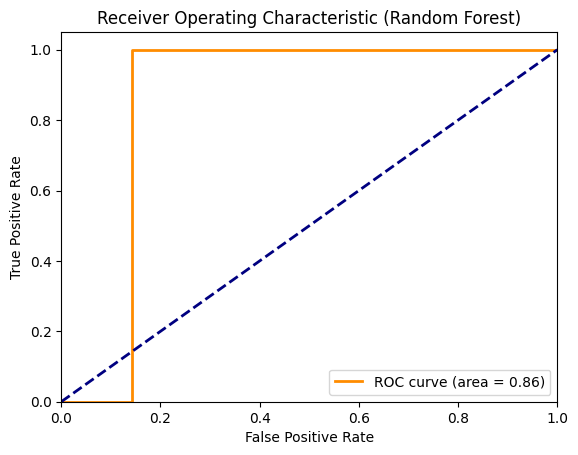

In [20]:
#特徴量をMFCCとしランダムフォレストを実行
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import numpy as np

# ... (他のimport文や前処理は省略) ...

# 特徴量抽出と機械学習 (ランダムフォレスト)
features = []
labels = []

for filename in os.listdir(output_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(output_dir, filename)
        y, sr = librosa.load(filepath)

        # MFCCの計算
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)  # 13次のMFCCを計算

        # MFCCの平均値を特徴量として使用
        mfcc_mean = np.mean(mfccs, axis=1)
        features.append(mfcc_mean)
        labels.append(ground_truth_labels[filename])

# 特徴量とラベルをNumPy配列に変換
features = np.array(features)
labels = np.array(labels)

# Convert labels to numerical values
labels_numeric = [1 if label == 'true' else 0 for label in labels]

# データを訓練データとテストデータに分割
X_train, X_test, y_train, y_test, _, y_test_filenames = train_test_split(
    features, labels_numeric, [filename for filename in os.listdir(output_dir) if filename.endswith('.wav')], test_size=0.2, random_state=42
)

# ランダムフォレストモデルを訓練
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# テストデータで予測 (確率値を取得)
y_pred_proba = model.predict_proba(X_test)

# ROC曲線を計算
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

# ROC曲線をプロット
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Random Forest)')
plt.legend(loc="lower right")
plt.show()

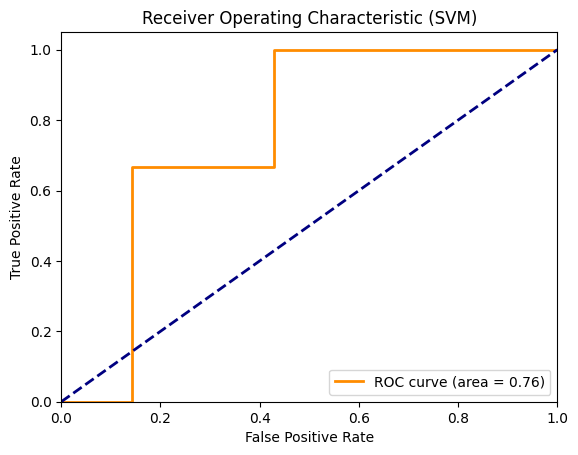

In [21]:
#特徴量をMFCCとしてSVMを実行
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
import numpy as np

# ... (他のimport文や前処理は省略) ...

# 特徴量抽出と機械学習 (SVM)
features = []
labels = []

for filename in os.listdir(output_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(output_dir, filename)
        y, sr = librosa.load(filepath)

        # MFCCの計算
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)  # 13次のMFCCを計算

        # MFCCの平均値を特徴量として使用
        mfcc_mean = np.mean(mfccs, axis=1)
        features.append(mfcc_mean)
        labels.append(ground_truth_labels[filename])

# 特徴量とラベルをNumPy配列に変換
features = np.array(features)
labels = np.array(labels)

# Convert labels to numerical values
labels_numeric = [1 if label == 'true' else 0 for label in labels]

# データを訓練データとテストデータに分割
X_train, X_test, y_train, y_test, _, y_test_filenames = train_test_split(
    features, labels_numeric, [filename for filename in os.listdir(output_dir) if filename.endswith('.wav')], test_size=0.2, random_state=42
)

# SVMモデルを訓練
model = SVC(kernel='linear', probability=True, random_state=42)  # probability=True for predict_proba
model.fit(X_train, y_train)

# テストデータで予測 (確率値を取得)
y_pred_proba = model.predict_proba(X_test)

# ROC曲線を計算
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

# ROC曲線をプロット
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (SVM)')
plt.legend(loc="lower right")
plt.show()

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# ... (他のimport文や前処理は省略) ...

# SVMモデルの作成と学習
svm_model = SVC(kernel='linear')  # 線形カーネルを使用
svm_model.fit(X_train, y_train)

# テストデータで予測
svm_y_pred = svm_model.predict(X_test)

# 精度を評価
svm_accuracy = accuracy_score(y_test, svm_y_pred)
print(f"SVM Accuracy: {svm_accuracy:.2f}")

# 予測結果をCSVファイルに保存 (SVM用)
with open('predicted_labels_svm.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])
    for i, filename in enumerate(test_filenames): # test_filenamesはtrain_test_splitで分割したテストデータのファイル名リスト
        writer.writerow([filename, svm_y_pred[i]])

print("predicted_labels_svm.csv が作成されました。")

SVM Accuracy: 0.70
predicted_labels_svm.csv が作成されました。
